Write a Python code that can perform the following tasks.
1. Read the CSV file, located on a given file path, into a pandas data frame, assuming that the first row of the file can be used as the headers for the data.
2. Print the first 5 rows of the dataframe to verify correct loading.

In [2]:
import pandas as pd

# Specify the file path
file_path = 'used_car_price_analysis.csv'

try:
    # Step 1: Read the CSV file into a pandas DataFrame with the first row as headers
    df = pd.read_csv(file_path, header=0)
    
    # Step 2: Print the first 5 rows of the DataFrame
    print("First 5 rows of the DataFrame:")
    print(df.head())
    
except FileNotFoundError:
    print(f"The file at path {file_path} was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

First 5 rows of the DataFrame:
     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [3]:
import numpy as np

Write a python code that performs the following tasks:
1. Identify the columns of a data frame with missing values.
2. Replace the missing values thus identified with mean value of the column.
3. Deletes the duplicate entries from the data frame.

In [9]:
# 1. Identify columns with missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()
print("Columns with missing values:", cols_with_missing)

# 2. Replace missing values with the mean of the column
for col in cols_with_missing:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)

# 3. Delete duplicate entries from the DataFrame
df.drop_duplicates(inplace=True)

print("\nDataFrame after filling missing values and dropping duplicates:")
print(df)


Columns with missing values: []

DataFrame after filling missing values and dropping duplicates:
         model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0       Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1        Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2        Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3       Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4       Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   
...        ...   ...          ...      ...      ...    ...   ...         ...   
17961    B-MAX  2017       Manual    16700   Petrol  150.0  47.1         1.4   
17962    B-MAX  2014       Manual    40700   Petrol   30.0  57.7         1.0   
17963    Focus  2015       Manual     7010   Diesel   20.0  67.3         1.6   
17964       KA  2018       Manual     5007   Petrol  145.0  57.7         1.2   
17965    Focus  2015   

Write a python code that identifies the top 5 attributes with highest correlation with the target attribute in a data frame.

In [11]:
target_col = 'price'

# Select numeric columns only (including target)
numeric_cols = df.select_dtypes(include='number').columns

if target_col not in numeric_cols:
    raise ValueError(f"Target column '{target_col}' must be numeric.")

# Compute correlations only on numeric columns
correlations = df[numeric_cols].corr()[target_col].drop(target_col)

# Top 5 attributes most correlated with price
top_5 = correlations.abs().sort_values(ascending=False).head(5)

print("Top 5 attributes most correlated with 'price':")
print(top_5)

Top 5 attributes most correlated with 'price':
year          0.635715
mileage       0.530483
engineSize    0.411451
tax           0.405970
mpg           0.346263
Name: price, dtype: float64


Write a python code that counts the number of entries in a dataframe with each unique value of a specific attribute (fuelType).

In [13]:
# Count entries for each unique value in 'fueltype'
fuel_counts = df['fuelType'].value_counts()

print("Count of unique values in 'fueltype':")
print(fuel_counts)

Count of unique values in 'fueltype':
fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


Write a python code that creates a Seaborn box plot between a source and target attributes of a dataframe.
Create a Box plot to determine whether cars with automatic, manual or semi-auto type of transmission have more price outliers. Use the Seaborn library for creating the plot.

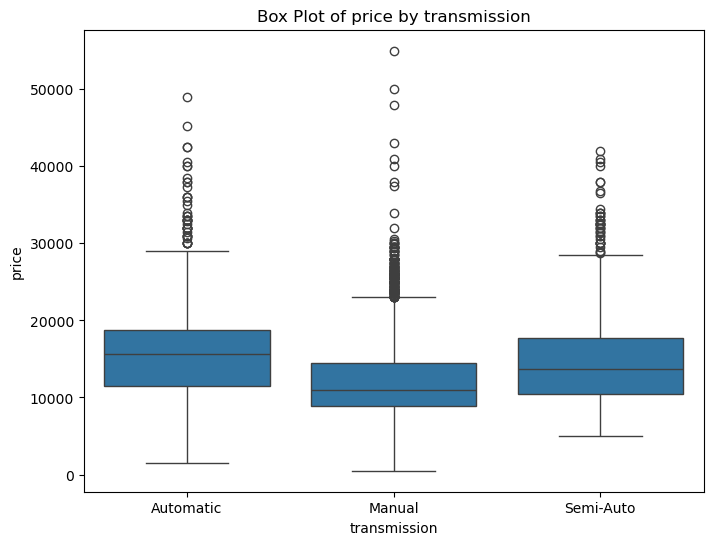

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Source and target attributes
source_col = 'transmission'  # categorical variable
target_col = 'price'         # numeric variable

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=source_col, y=target_col, data=df)
plt.title(f'Box Plot of {target_col} by {source_col}')
plt.show()


Generate the regression plot between mpg parameter and the price to determine the correlation type between the two.
Write a python code that creates a regression plot between a source attribute and a target attribute.

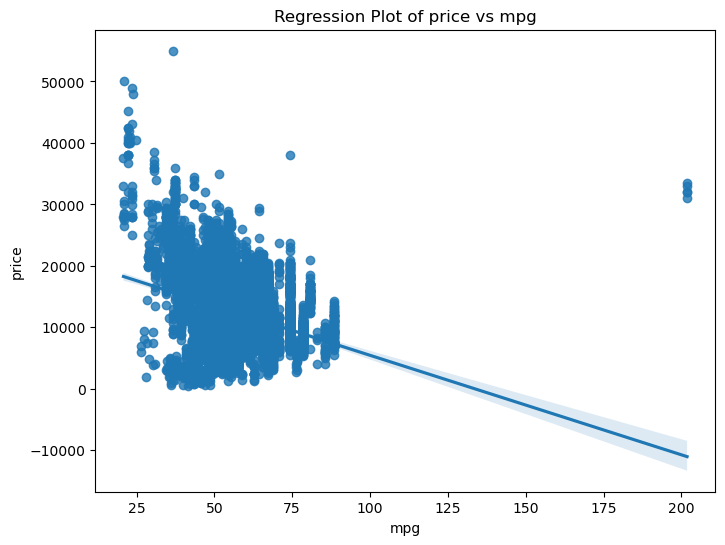

In [17]:
# Create regression plot
plt.figure(figsize=(8, 6))
sns.regplot(x='mpg', y='price', data=df)
plt.title('Regression Plot of price vs mpg')
plt.xlabel('mpg')
plt.ylabel('price')
plt.show()

Fit a linear regression model to predict the price using the feature mpg. Then calculate the R^2 and MSE values for the model.
Write a python code to fit a linear regression model on a target variable on basis of a source variable. Calculate the R^2 values and MSE values for this model.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[['mpg']]  # Feature matrix (2D)
y = df['price']  # Target vector

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict on the training data
y_pred = model.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.2f}")


R^2: 0.1199
MSE: 19741690.81


Fit a linear regression model to predict the price using the following set of features.
year, mileage, tax, mpg and engineSize.
Calculate the R^2 and MSE values for this model.

Write a python code to fit a linear regression model on a target variable on basis of a set of source variables. Calculate the R^2 values and MSE values for this model.

In [20]:
# Features and target
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features]
y = df['price']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predict on training data
y_pred = model.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.2f}")


R^2: 0.7265
MSE: 6134065.22


Write a python code that can perform the following tasks.

1. Create a pipeline with standard scalar, second degree polynomial features and linear regression model.
2. Fit this pipeline for a target variable using a set of source attributes from a dataframe.
3. Evaluate the R^2 and MSE values for the trained model.

In [21]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define features and target
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target = 'price'

X = df[features]
y = df[target]

# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression())
])

# Fit the model
pipeline.fit(X, y)

# Predict on training data
y_pred = pipeline.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.2f}")


R^2: 0.7667
MSE: 5234038.07


Write a python code that can perform the following tasks.

1. Assuming that a subset of the attributes of a data frame are source attributes and one of the attributes is a target attribute, split the data into training and testing data assuming the testing data to be 20%.
2. Create and fit a Ridge regression model using the training data, setting the regularization parameter to 0.1.
3. Calculate the MSE and R^2 values for the Ridge Regression model using the testing data.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Features and target
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target = 'price'

X = df[features]
y = df[target]

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)

# Fit the model on training data
ridge_model.fit(X_train, y_train)

# Predict on test data
y_pred = ridge_model.predict(X_test)

# Calculate R^2 on test data
r2_test = r2_score(y_test, y_pred)

print(f"R^2 on test data: {r2_test:.4f}")


R^2 on test data: 0.6917


Write a python code that can perform the following tasks.

1. Assuming that a subset of the attributes of a data frame are source attributes and one of the attributes is a target attribute, split the data into training and testing data assuming the testing data to be 20%.
2. Apply second degree polynomial scaling to the training and testing data.
3. Create and fit a Ridge regression model using the training data, setting the regularization parameter to 0.1.
4. Calculate the MSE and R^2 values for the Ridge Regression model using the testing data.

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Define source attributes and target
source_attributes = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target_attribute = 'price'

X = df[source_attributes]
y = df[target_attribute]

# 1. Split data into train and test sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Apply second degree polynomial features to train and test
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3. Create and fit Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_poly, y_train)

# 4. Predict on test data and calculate MSE and R^2
y_pred = ridge_model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE on test data: {mse:.2f}")
print(f"R^2 on test data: {r2:.4f}")


MSE on test data: 7326174.88
R^2 on test data: 0.6733


C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Write a python code that can perform the following tasks.

1. Assuming that a subset of the attributes of a data frame are source attributes and one of the attributes is a target attribute, split the data into training and testing data assuming the testing data to be 20%.
2. Apply second degree polynomial scaling to the training and testing data.
3. Create and fit a Grid search on Ridge regression with cross validation using the training data, for a set of values of the parameter alpha.
4. Calculate the MSE and R^2 values for the Ridge Regression model using the testing data.

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define source attributes and target
source_attributes = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target_attribute = 'price'

X = df[source_attributes]
y = df[target_attribute]

# Split into train/test (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2 & 3. Create a pipeline with polynomial features and Ridge regression, then use GridSearchCV
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

# Grid of alpha values to search over
param_grid = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Fit grid search on training data
grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_

# 4. Predict on test data and evaluate
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best alpha: {grid_search.best_params_['ridge__alpha']}")
print(f"MSE on test data: {mse:.2f}")
print(f"R^2 on test data: {r2:.4f}")


C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.81616e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.8643e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.85145e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.82541e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-pac

Best alpha: 0.01
MSE on test data: 13840986.00
R^2 on test data: 0.3827


C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.62094e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.61606e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.61037e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.52253e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\AnacondaMarch2025\Lib\site-pa